In [10]:
import os
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from metient.util import plotting_util as putil
import sys
sys.path.append(os.path.join(os.getcwd(), "notebooks/calibrate_analysis"))
import calibrate_analysis_utilities as ut

REPO_DIR = '/lila/data/morrisq/divyak/projects/metient/data'
OUTPUT_DIR = os.path.join(REPO_DIR, '../notebooks', 'output_plots')

DATE = "04162025"
BOOTSTRAP_FN = os.path.join(REPO_DIR, '../notebooks/calibrate_analysis/fit_thetas', f'thetas_split_on_same_cohort_100_bootstraps_{DATE}.csv')

four_dataset_colors = {"Melanoma":"#b84988","HGSOC":"#06879e","HR-NB":"#5a9e09", "NSCLC":"#d4892a"}

DATASET_NAMES = [ "HGSOC", "Melanoma", "HR-NB", "NSCLC"]
CALIBRATE_DIRS = [os.path.join(REPO_DIR,f"mcpherson_ovarian_2016/metient_outputs/hgsoc_bs8192_runs100_solvepolys_{DATE}_r2/calibrate"),
                  os.path.join(REPO_DIR,f"sanborn_melanoma_2015/metient_outputs/melanoma_bs8192_runs100_solvepolys_{DATE}_r2/calibrate"),
                  os.path.join(REPO_DIR,f"gundem_neuroblastoma_2023/metient_outputs/hrnb_bs8192_runs100_solvepolys_{DATE}_r2/calibrate"),
                  os.path.join(REPO_DIR,f"tracerx_nsclc/metient_outputs/tracerx_trees_bs8192_runs100_{DATE}_r2/calibrate",)]
SEEDING_PATTERN_ORDER = ["single-source", 'multi-source', "reseeding", "primary single-source"]

### Load all calibrate inferred trees

What are different metrics (e.g. seeding pattern, clonality, phyleticity) for the top tree, as determined by calibrate? or by a seeding site penalizing model? or migration number penalizing model?

In [11]:
import warnings
warnings.filterwarnings('ignore')

trees_df = ut.build_top_calibrate_tree_df(CALIBRATE_DIRS, DATASET_NAMES, BOOTSTRAP_FN)

HGSOC 13
Melanoma 7
HR-NB 30
NSCLC 128
Not LUAD or LUSC subtype CRUK0702
Not LUAD or LUSC subtype CRUK0514
Not LUAD or LUSC subtype CRUK0325
Not LUAD or LUSC subtype CRUK0718
Not LUAD or LUSC subtype CRUK0422
Not LUAD or LUSC subtype CRUK0596
Not LUAD or LUSC subtype CRUK0476
Not LUAD or LUSC subtype CRUK0719
Not LUAD or LUSC subtype CRUK0100
Not LUAD or LUSC subtype CRUK0557
Not LUAD or LUSC subtype CRUK0099
Not LUAD or LUSC subtype CRUK0587
Not LUAD or LUSC subtype CRUK0524
Not LUAD or LUSC subtype CRUK0484
Not LUAD or LUSC subtype CRUK0769
Not LUAD or LUSC subtype CRUK0097
Not LUAD or LUSC subtype CRUK0698
Not LUAD or LUSC subtype CRUK0640
Not LUAD or LUSC subtype CRUK0013
Not LUAD or LUSC subtype CRUK0598
Not LUAD or LUSC subtype CRUK0245
Average number of nodes 13.865168539325843


In [12]:
trees_df[(trees_df['Dataset']=='HR-NB')&(trees_df['Majority vote seeding pattern']!='primary single-source')]

,Dataset,Patient id,Filename,Lowest cal loss,Subtype,Num sites,Num trees on Pareto,Multiple trees w/ same pars metrics,Multiple trees w/ diff pars metrics,Root clone observed site,Top cal seeding pattern,Top cal site clonality,Top cal genetic clonality,Top cal phyleticity,Top cal tracerx phyleticity,Top cal % migs poly,Top cal num ss,Top cal seeding clusters,Top cal % metastatic sites,Lowest mig seeding pattern,Lowest mig % migs poly,Lowest mig num ss,Lowest comig seeding pattern,Lowest comig % migs poly,Lowest comig num ss,Lowest ss seeding pattern,Lowest ss % migs poly,Lowest ss num ss,Lowest ss seeding clusters,Pars metrics,Majority vote seeding pattern,Majority vote site clonality,Majority vote genetic clonality,Majority vote phyleticity,All % migs poly,All num ss,All % met sites,All bootstrap patterns
7,HR-NB,H103207,/lila/data/morrisq/divyak/projects/metient/dat...,260.548,N/A,6,13,False,True,None,single-source,polyclonal,polyclonal,polyphyletic,polyphyletic,40.000,3,"[3, 10, 12, 14, 18, 26]",40.000,single-source,40.000,3,single-source,40.000,3,primary single-source,60.000,1,"[2, 3, 4, 12, 13, 18, 26, 29]","[(7, 5, 3), (7, 5, 3), (7, 5, 3), (7, 5, 3), (...",single-source,polyclonal,polyclonal,polyphyletic,"[40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40....","[3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 1]","[40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40....","[single-source, single-source, single-source, ..."
16,HR-NB,H118706,/lila/data/morrisq/divyak/projects/metient/dat...,332.933,N/A,6,2,False,True,None,single-source,polyclonal,polyclonal,polyphyletic,polyphyletic,100.000,2,"[1, 34, 35, 7, 8, 12, 17, 21, 22, 23]",20.000,single-source,100.000,2,single-source,100.000,2,primary single-source,100.000,1,"[1, 34, 35, 7, 8, 12, 15, 21, 22, 23, 30, 31]","[(12, 5, 2), (17, 5, 1)]",single-source,polyclonal,polyclonal,polyphyletic,"[100.0, 100.0]","[2, 1]","[20.0, 0.0]","[single-source, single-source, single-source, ..."
24,HR-NB,H132384,/lila/data/morrisq/divyak/projects/metient/dat...,157.079,N/A,4,2,False,True,Distant,single-source,polyclonal,polyclonal,monophyletic,polyphyletic,33.333,2,"[2, 12, 5, 6]",33.333,single-source,33.333,2,single-source,33.333,2,primary single-source,33.333,1,"[2, 12, 5, 6]","[(4, 3, 2), (5, 3, 1)]",single-source,polyclonal,polyclonal,monophyletic,"[33.33333333333333, 33.33333333333333]","[2, 1]","[33.33333333333333, 0.0]","[single-source, single-source, single-source, ..."
28,HR-NB,H132396,/lila/data/morrisq/divyak/projects/metient/dat...,118.716,N/A,3,3,False,True,None,single-source,polyclonal,polyclonal,monophyletic,monophyletic,50.000,2,"[1, 2]",50.000,single-source,50.000,2,single-source,50.000,2,primary single-source,100.000,1,"[1, 2, 3, 7]","[(3, 2, 2), (3, 2, 2), (4, 2, 1)]",single-source,polyclonal,polyclonal,monophyletic,"[50.0, 50.0, 100.0]","[2, 2, 1]","[50.0, 50.0, 0.0]","[single-source, single-source, single-source, ..."
31,HR-NB,H134819,/lila/data/morrisq/divyak/projects/metient/dat...,154.332,N/A,3,3,False,True,None,single-source,polyclonal,polyclonal,polyphyletic,polyphyletic,100.000,2,"[7, 16, 17, 24, 25]",50.000,single-source,100.000,2,single-source,100.000,2,primary single-source,100.000,1,"[0, 2, 4, 7, 9, 13, 17, 24, 25]","[(5, 2, 2), (5, 2, 2), (9, 2, 1)]",single-source,polyclonal,polyclonal,polyphyletic,"[100.0, 100.0, 100.0]","[2, 2, 1]","[50.0, 50.0, 0.0]","[single-source, single-source, single-source, ..."
32,HR-NB,H134821,/lila/data/morrisq/divyak/projects/metient/dat...,365.676,N/A,7,8,False,True,None,single-source,polyclonal,polyclonal,polyphyletic,polyphyletic,66.667,3,"[0, 2, 6, 10, 11, 14, 16, 18, 23]",33.333,multi-source,42.857,3,single-source,66.667,3,primary single-source,66.667,1,"[0, 4, 5, 6, 10, 11, 12, 14, 16, 17, 18, 23]","[(12, 6, 3), (11, 7, 3), (11, 7, 3), (13, 6, 2...",multi-source,polyclonal,polyclonal,polyphyletic,"[66.66666666666666, 42.857142857142854, 42.857...","[3, 3, 3, 2, 2, 2, 2, 1]","[33.33333333333333, 33.33333333333333, 33.3333...","[multi-source, multi

In [13]:
pids = []
for i, row in trees_df.iterrows():
    if len(set(row['Pars metrics'])) >= 3:
        #print(row['Patient id'], len(set(row['Pars metrics'])))
        pids.append(row['Patient id'])
print("Patients with 3 or more unique pars metrics", pids)

Patients with 3 or more unique pars metrics ['H103207', 'H134821', 'CRUK0290', 'CRUK0487', 'CRUK0559']


### How many sites are seeded by more than one clone?

In [14]:
polyclonally_seeded_sites, total_seeded_sites = ut.get_polyclonally_seeded_sites_and_total_seeded_sites(trees_df)

print(f"Number of polyclonally seeded sites: {polyclonally_seeded_sites}")
print(f"Total number of seeded sites: {total_seeded_sites}")
print(f"Fraction of sites that are polyclonally seeded: {float(polyclonally_seeded_sites/total_seeded_sites):.3f}")

Number of polyclonally seeded sites: 103
Total number of seeded sites: 312
Fraction of sites that are polyclonally seeded: 0.330


### Visualize pareto optimal metrics in radar plots

Patients with 3 or more pareto front trees ['1', 'H103207', 'H132374', 'H132396', 'H134819', 'H134821', 'CRUK0245', 'CRUK0290', 'CRUK0487', 'CRUK0559', 'CRUK0620', 'CRUK0698', 'CRUK0748', 'CRUK0810']
[(7, 5, 3), (8, 5, 2), (11, 5, 1)]
[(6, 2, 2), (5, 4, 3), (8, 2, 1)]
H103207
CRUK0290


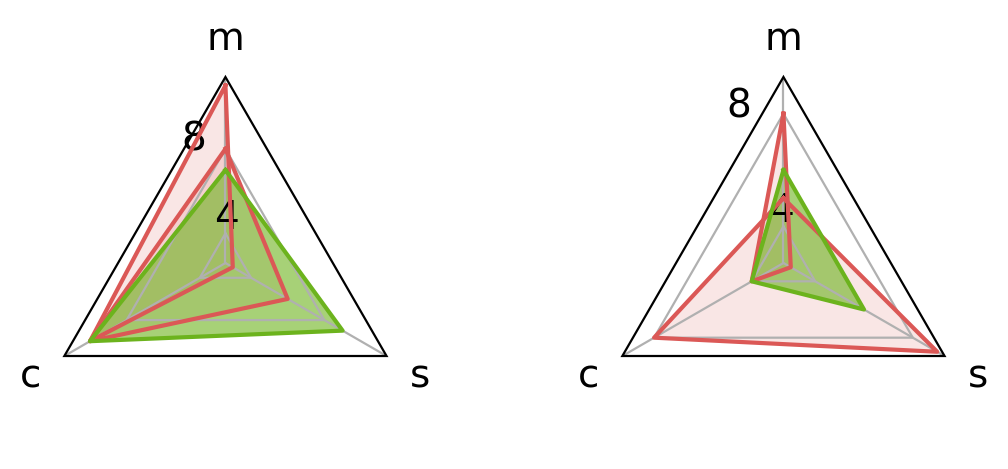

In [15]:

pids = []
for i, row in trees_df.iterrows():
    if len(row['Pars metrics']) >= 3:
        #print(row['Patient id'], len(set(row['Pars metrics'])))
        pids.append(row['Patient id'])
print("Patients with 3 or more pareto front trees", pids)
N = 3
theta = ut.radar_factory(N, frame='polygon')
pids = ['H103207','CRUK0290']
data = ut.get_patient_pars_metrics(trees_df, pids)
spoke_labels = data.pop(0)

fig, axs = plt.subplots(figsize=(6, 3), nrows=1, ncols=2,
                        subplot_kw=dict(projection='radar'),dpi=200)
fig.subplots_adjust(wspace=0.5, hspace=0.20, top=0.85, bottom=0.05)

# Plot the four cases from the example data on separate Axes
for ax, (title, case_data) in zip(axs.flat, data):
    ax.set_rgrids([0,4,8,12])
    print(title)
    title = f"NSCLC patient {title}" if title.startswith('CRUK') else f"HR-NB patient {title}"
    # ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.3),
    #              horizontalalignment='center', verticalalignment='top', fontsize=12)
    colors = ["#db5856" for _ in range(len(case_data)-1)]+["#6cb31d"]
    alphas = [0.15 for _ in range(len(case_data)-1)]+[0.6]
    for d, color, alpha in zip(case_data, colors, alphas):
        ax.plot(theta, d, color=color)
        ax.fill(theta, d, facecolor=color, alpha=alpha, label='_nolegend_')
    ax.set_varlabels([x[0].lower() for x in spoke_labels])
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.savefig(os.path.join(OUTPUT_DIR, f"pareto_treadeoff_examples.png"), dpi=300,  bbox_inches='tight', pad_inches=0.1)

plt.show()

In [16]:
# How many total sites do we have across all patients
print("Unique anatomical sites", sum(trees_df.groupby('Patient id')['Num sites'].mean()))

# how many unique patients
print("Unique patients", len(trees_df['Patient id'].unique()))


Unique anatomical sites 479.0
Unique patients 167


### How many patients have the root clone detected in a met?

Unique patients with a root clone observed in met: 30
1 5 0
0 4 0
0 5 0
10 4 1
    Dataset  Root clone in LN  Root clone in distant  Root clone in both
0  Melanoma            14.286                 71.429               0.000
1     HGSOC             0.000                 57.143               0.000
2     HR-NB             0.000                 18.519               0.000
3     NSCLC             7.937                  3.175               0.794


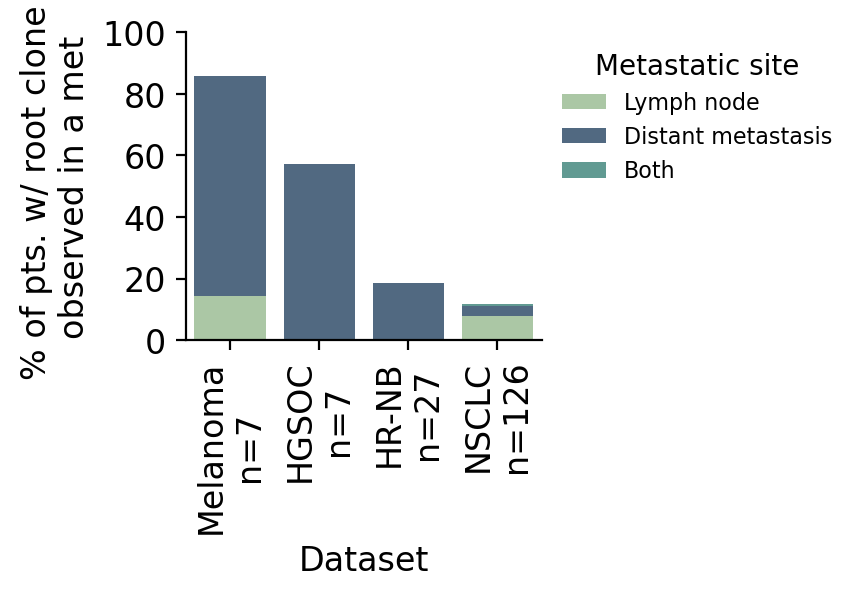

In [17]:

def adjust_lightness(hex_color, amount=0.5):
    import colorsys
    import matplotlib.colors as mc
    h = hex_color.strip("#")
    c = tuple(float(int(h[i:i+2], 16)/256) for i in (0, 2, 4))
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

print("Unique patients with a root clone observed in met:", len(trees_df[trees_df['Root clone observed site']!='None']['Patient id'].unique()))

root_clone_in_ln_met_df = trees_df[(trees_df['Root clone observed site']=='Lymph node')]
root_clone_in_other_met_df = trees_df[(trees_df['Root clone observed site']=='Distant')]
root_clone_in_both_df = trees_df[(trees_df['Root clone observed site']=='Both')]

data = []
for dataset in four_dataset_colors.keys():
    num_tot_pts = len(trees_df[trees_df['Dataset']==dataset]['Patient id'].unique())
    num_root_clone_in_ln_met_pts = len(root_clone_in_ln_met_df[(root_clone_in_ln_met_df['Dataset']==dataset)]['Patient id'].unique())
    num_root_clone_in_other_met_pts = len(root_clone_in_other_met_df[(root_clone_in_other_met_df['Dataset']==dataset)]['Patient id'].unique())
    num_root_clone_both_met_pts = len(root_clone_in_both_df[(root_clone_in_both_df['Dataset']==dataset)]['Patient id'].unique())

    print(num_root_clone_in_ln_met_pts,num_root_clone_in_other_met_pts, num_root_clone_both_met_pts )
    data.append([dataset, 100*(num_root_clone_in_ln_met_pts/num_tot_pts), 100*(num_root_clone_in_other_met_pts/num_tot_pts), 100*(num_root_clone_both_met_pts/num_tot_pts)])

root_clone_df = pd.DataFrame(data, columns=['Dataset', 'Root clone in LN', 'Root clone in distant', 'Root clone in both'])
print(root_clone_df)
plt.figure(figsize=(2.3, 2), dpi=200)
ln_colors = ['#A8CD9F']
distant_colors = ['#496989']
both_colors = ['#58A399']
sns.barplot(x='Dataset', y='Root clone in LN', data=root_clone_df, palette=ln_colors, order=four_dataset_colors.keys(), label="Lymph node")
sns.barplot(x='Dataset', y='Root clone in distant', data=root_clone_df, palette=distant_colors, order=four_dataset_colors.keys(), label="Distant metastasis", bottom=root_clone_df['Root clone in LN'])
snsfig=sns.barplot(x='Dataset', y='Root clone in both', data=root_clone_df, palette=both_colors, order=four_dataset_colors.keys(), label="Both", bottom=root_clone_df['Root clone in distant']+root_clone_df['Root clone in LN'])
# snsfig = sns.barplot(x=DATASET_NAMES[1:], y=ys, palette=four_dataset_colors.values(), order=four_dataset_colors.keys())
plt.ylabel("% of pts. w/ root clone \nobserved in a met", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
handles, labels = snsfig.get_legend_handles_labels()  # Get existing handles and labels

legend = snsfig.legend(handles=handles, labels=labels, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, 
           frameon=False, fontsize=8)
legend.set_title("Metastatic site", prop={'size': 10}) 

plt.ylim(0,100)
name_mapping = {
                dataset: f"{dataset}\nn={len(trees_df[trees_df['Dataset']==dataset]['Patient id'].unique())}"
                    for dataset in ['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma']
               }
snsfig.set_xticklabels([name_mapping[label.get_text()] for label in snsfig.get_xticklabels()], 
                        rotation=90, horizontalalignment='center', fontsize=12)
snsfig.set_yticklabels(snsfig.get_yticklabels(), fontsize=12)
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR, f"percent_pts_root_clone_in_met.png"), dpi=300,  bbox_inches='tight', pad_inches=0.3)


### How many trees are on the Pareto front?

In [18]:
one_met_df = trees_df[trees_df['Num sites'] == 2]
multi_met_df = trees_df[trees_df['Num sites'] > 2]
three_met_df = trees_df[trees_df['Num sites'] > 3]

print("Average number of pareto front trees with 1 met:", one_met_df['Num trees on Pareto'].mean())
print("Average number of pareto front trees with > 1 met:", multi_met_df['Num trees on Pareto'].mean())
print("Average number of pareto front trees:", trees_df['Num trees on Pareto'].mean())
print("Max number of pareto front trees:", trees_df['Num trees on Pareto'].max())

# Number of patients with multiple trees
percent_patients = 100*len(trees_df[(trees_df['Multiple trees w/ same pars metrics']==1)|(trees_df['Multiple trees w/ diff pars metrics']==1)])/len(trees_df)
print("Percent of patients with multiple trees:", percent_patients, len(trees_df[(trees_df['Multiple trees w/ same pars metrics']==1)|(trees_df['Multiple trees w/ diff pars metrics']==1)]))

# Number of patients with multiple trees and > 1 met
percent_patients = 100*len(multi_met_df[(multi_met_df['Multiple trees w/ same pars metrics']==1)|(multi_met_df['Multiple trees w/ diff pars metrics']==1)])/len(multi_met_df)
print("Percent of patients with multiple trees and > 1 met:", percent_patients, len(multi_met_df[(multi_met_df['Multiple trees w/ same pars metrics']==1)|(multi_met_df['Multiple trees w/ diff pars metrics']==1)]),"/", len(multi_met_df))

# Number of patients with multiple trees and > 2 met
percent_patients = 100*len(three_met_df[(three_met_df['Multiple trees w/ same pars metrics']==1)|(three_met_df['Multiple trees w/ diff pars metrics']==1)])/len(three_met_df)
print("Percent of patients with multiple trees and > 2 met:", percent_patients, len(three_met_df[(three_met_df['Multiple trees w/ same pars metrics']==1)|(three_met_df['Multiple trees w/ diff pars metrics']==1)]),"/", len(three_met_df))


# How many patients have a pareto front with multiple trees with the same parsimony metric
percent_patients = 100*len(trees_df[trees_df['Multiple trees w/ same pars metrics']==1])/len(trees_df)
print("Percent of patients with multiple trees w/ same parsimony metric:", percent_patients, len(trees_df[trees_df['Multiple trees w/ same pars metrics']==1]))

# How many patients have a pareto front with multiple trees with different parsimony metrics
percent_patients = 100*len(trees_df[trees_df['Multiple trees w/ diff pars metrics']==1])/len(trees_df)
print("Percent of patients with multiple trees w/ different parsimony metric:", percent_patients, len(trees_df[trees_df['Multiple trees w/ diff pars metrics']==1]))

# sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
# plt.figure(figsize=(2, 2), dpi=100)
# snsfig = sns.boxplot(data=[one_met_df['Num trees on Pareto'], multi_met_df['Num trees on Pareto']], 
#             width=0.5, palette="Set3")
# plt.ylabel("Number of trees on\napproximate Pareto front", fontsize=8)
# plt.xticks([0, 1], ['1', '> 1'])
# snsfig.spines['top'].set_visible(False)
# snsfig.spines['right'].set_visible(False)

Average number of pareto front trees with 1 met: 1.0
Average number of pareto front trees with > 1 met: 2.276315789473684
Average number of pareto front trees: 1.5808383233532934
Max number of pareto front trees: 32
Percent of patients with multiple trees: 17.964071856287426 30
Percent of patients with multiple trees and > 1 met: 39.473684210526315 30 / 76
Percent of patients with multiple trees and > 2 met: 52.94117647058823 18 / 34
Percent of patients with multiple trees w/ same parsimony metric: 0.0 0
Percent of patients with multiple trees w/ different parsimony metric: 17.964071856287426 30


### What is the average genetic distance on migrating vs. non-migrating edges for patients with only one history on the pareto front

137
T-statistic: 5.381648798096854, p = 1.4251607967585833e-07


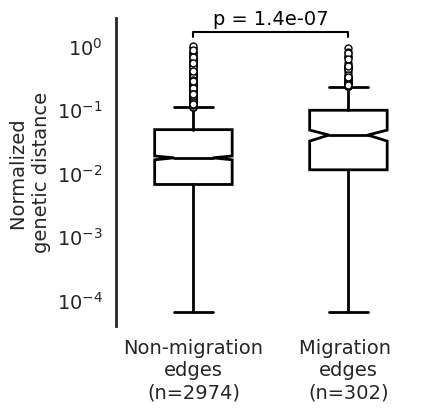

(0.045453246682045596, 0.09002359562897701)

In [19]:
from scipy import stats
import gzip
import pickle
from metient.util.globals import *
import numpy as np
from metient.util import data_extraction_util as dutil

def gen_dist_boxplot(migrating, nonmigrating):
    df = pd.DataFrame({
        'Normalized \ngenetic distance': np.concatenate([nonmigrating, migrating]),
        '.': [f'Non-migration\nedges\n(n={len(nonmigrating)})']*len(nonmigrating)+[f'Migration \nedges\n(n={len(migrating)})']*len(migrating)
    })

    t_stat, p_value = stats.ttest_ind(migrating, nonmigrating,equal_var=False)
    print(f"T-statistic: {t_stat}, p = {p_value}")

    sns.set(style="white")

    plt.figure(figsize=(4, 4))
    ax = sns.boxplot(x='.', y='Normalized \ngenetic distance', data=df, width=0.5, showfliers=True, 
                    notch=True,
                    flierprops={'marker': 'o', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
                    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2, alpha=1),
                    whiskerprops=dict(color='black', linewidth=2, alpha=1),
                    medianprops=dict(color='black', linewidth=2, alpha=1),
                    capprops=dict(color='black', linewidth=2, alpha=1))

    x1, x2 = 0, 1  # locations for the groups to annotate
    y, h, col = df['Normalized \ngenetic distance'].max() + 0.4, 0.3, 'black'

    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h+0.2, f"p = {p_value:.1e}", ha='center', va='bottom', color=col, fontsize=14)
    plt.yscale('log')
    ax.spines['left'].set_linewidth(2)
    ax.tick_params(axis='y', length=6, width=2)
    ax.yaxis.set_tick_params(which='both', width=2)  # Also style minor ticks
    sns.despine()
    plt.ylabel('Normalized \ngenetic distance', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.xlabel('')
    ax.spines['bottom'].set_visible(False)
    plt.savefig(os.path.join(OUTPUT_DIR, f"migrating_vs_nonmigrating_edges.png"), dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()
    
single_pareto_soln = trees_df[trees_df['Num trees on Pareto']==1]
print(len(single_pareto_soln))

non_migrating_edges, migrating_edges = [],[]
for fn in single_pareto_soln['Filename']:
    with gzip.open(fn, 'rb') as f:
        pkl = pickle.load(f)
        gen_dist = torch.tensor(pkl[OUT_GEN_DIST_KEY][0])
        V = torch.tensor(pkl[OUT_LABElING_KEY][0])
        A = dutil.adjacency_matrix_from_parents(pkl[OUT_ADJ_KEY][0]).to_dense()
        X = V.T @ V # 1 if two nodes are the same color
        # Calculate if 2 nodes are in diff sites and there's an edge between them (i.e there is a migration edge)
        R = torch.mul(A, (1-X))
        #print(torch.nonzero(R))
        # Calculate if 2 nodes are in same site and there's an edge between them (i.e there is no migration edge)
        Y = torch.mul(A, X)
        #print(torch.nonzero(Y))
        migrating_edges_gen_dist = torch.mul(R, gen_dist)
        migrating_edges_gen_dist = migrating_edges_gen_dist[migrating_edges_gen_dist!=0].tolist()
        nonmigrating_edges_gen_dist = torch.mul(Y, gen_dist)
        nonmigrating_edges_gen_dist = nonmigrating_edges_gen_dist[nonmigrating_edges_gen_dist!=0].tolist()

        non_migrating_edges.extend(nonmigrating_edges_gen_dist)
        migrating_edges.extend(migrating_edges_gen_dist)
gen_dist_boxplot(migrating_edges, non_migrating_edges)
avg_migrating_edges_gen_dist = sum(migrating_edges)/len(migrating_edges)
avg_nonmigrating_edges_gen_dist = sum(non_migrating_edges)/len(non_migrating_edges)
avg_nonmigrating_edges_gen_dist,avg_migrating_edges_gen_dist 

### How different are the colonizing clones from Metient vs. seeding site penalizing model?

In [20]:
num_same_clones = 0
num_diff_clones = 0
num_pts_diff_clones = 0
for i,row in trees_df.iterrows():
    top_cal_clusters = set(row['Top cal seeding clusters'])
    lowest_ss_clusters = set(row['Lowest ss seeding clusters'])
    num_same_clones += len(top_cal_clusters.intersection(lowest_ss_clusters))
    num_diff_clones += len(top_cal_clusters.symmetric_difference(lowest_ss_clusters))
    if len(top_cal_clusters.symmetric_difference(lowest_ss_clusters)) != 0:
        num_pts_diff_clones += 1

print("same clones", num_same_clones, "diff clones", num_diff_clones, "num_pts_diff_clones", num_pts_diff_clones)

same clones 393 diff clones 46 num_pts_diff_clones 20


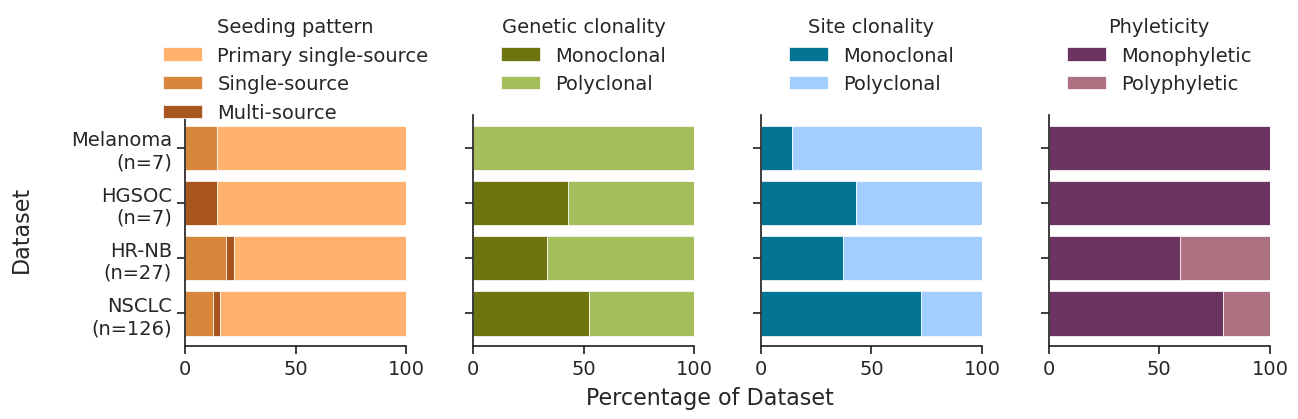

In [51]:
def horizontal_bar(ax, proportions, desired_order, legend_title, colors, legend_order=None):
    """Create a horizontal bar plot with stacked bars."""
    bottoms = np.zeros(len(proportions))
    
    for column_name in desired_order:
        if column_name not in proportions.columns:
            continue
        column_data = proportions[column_name]
        ax.barh(proportions.index, column_data, left=bottoms, label=column_name,
               color=colors[column_name], edgecolor='white', linewidth=0.5)
        bottoms += column_data.values

    ax.set_xlabel('Percentage of Dataset')
    ax.set_ylabel('Dataset', fontsize=16)
    legend_order = desired_order if legend_order is None else legend_order
    handles, labels = ax.get_legend_handles_labels()
    # Reorder handles and labels based on legend_order
    ordered_handles = []
    ordered_labels = []
    for item in legend_order:
        if item in labels:
            idx = labels.index(item)
            ordered_handles.append(handles[idx])
            ordered_labels.append(labels[idx])
    
    legend = ax.legend(ordered_handles, ordered_labels, title=legend_title, 
                      bbox_to_anchor=(0.5, 1.5), loc='upper center', 
                      frameon=False, fontsize=14)
    legend.get_title().set_fontsize(14)
    for text in legend.get_texts():
        text.set_text(text.get_text().capitalize())
    
    ax.tick_params(axis='both', labelsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set up the figure
height = 3
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,height), 
                                        sharey=True, sharex=True, 
                                        gridspec_kw={'wspace': 0.3})
sns.set(style='ticks', font="Arial")

# Prepare data
df = trees_df
df['Majority vote phyleticity'] = df['Majority vote phyleticity'].apply(str.capitalize)
df['Majority vote genetic clonality'] = df['Majority vote genetic clonality'].apply(str.capitalize)
df['Majority vote site clonality'] = df['Majority vote site clonality'].apply(str.capitalize)

# Create dataset labels with counts
name_mapping = {
    dataset: f"{dataset}\n(n={len(df[df['Dataset']==dataset]['Patient id'].unique())})"
    for dataset in ['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma']
}

tab_colors = ["#d8863b", "#a9561e", "#e59e43", "#ffb16d"]

# Plot 1: Seeding Pattern
seeding_pattern_counts = df.groupby(['Dataset', 'Majority vote seeding pattern']).size().unstack(fill_value=0)
seeding_pattern_proportions = seeding_pattern_counts.div(seeding_pattern_counts.sum(axis=1), axis=0)*100
seeding_pattern_proportions = seeding_pattern_proportions.reindex(['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma'])
seeding_pattern_proportions.rename(index=name_mapping, inplace=True)
desired_order = ["single-source", 'multi-source', "reseeding", "primary single-source"]
colors = dict(zip(desired_order, tab_colors))
horizontal_bar(ax1, seeding_pattern_proportions, desired_order, "Seeding pattern", colors, ["primary single-source", "single-source", 'multi-source', "reseeding", ])


#colors = ["#CF9D68", "#EAA849", "#DE7B50", "#D55D64", "#CA578A", "#A14985", "#6FA295", "#449898", "#3982A6", "#2C5BA3"]

# Plot 2: Genetic Clonality
genetic_clonality_counts = df.groupby(['Dataset', 'Majority vote genetic clonality']).size().unstack(fill_value=0)
genetic_clonality_proportions = genetic_clonality_counts.div(genetic_clonality_counts.sum(axis=1), axis=0)*100
genetic_clonality_proportions = genetic_clonality_proportions.reindex(['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma'])
genetic_clonality_proportions.rename(index=name_mapping, inplace=True)
desired_order = ["Monoclonal", "Polyclonal"]
colors = dict(zip(desired_order, ["#6e750e", "#a4be5c"]))
horizontal_bar(ax2, genetic_clonality_proportions, desired_order, "Genetic clonality", colors)

# Plot 3: Site Clonality
site_clonality_counts = df.groupby(['Dataset', 'Majority vote site clonality']).size().unstack(fill_value=0)
site_clonality_proportions = site_clonality_counts.div(site_clonality_counts.sum(axis=1), axis=0)*100
site_clonality_proportions = site_clonality_proportions.reindex(['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma'])
site_clonality_proportions.rename(index=name_mapping, inplace=True)
colors = dict(zip(desired_order, ["#047495", "#a2cffe"]))
horizontal_bar(ax3, site_clonality_proportions, desired_order, "Site clonality", colors)

# Plot 4: Phyleticity
phyletic_counts = df.groupby(['Dataset', 'Majority vote phyleticity']).size().unstack(fill_value=0)
phyletic_proportions = phyletic_counts.div(phyletic_counts.sum(axis=1), axis=0)*100
phyletic_proportions = phyletic_proportions.reindex(['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma'])
phyletic_proportions.rename(index=name_mapping, inplace=True)
desired_order = ["Monophyletic", "Polyphyletic"]
colors = dict(zip(desired_order, ["#6c3461", "#ae7181"]))
horizontal_bar(ax4, phyletic_proportions, desired_order, "Phyleticity", colors)

# Adjust labels and layout
ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')
ax4.set_ylabel('')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
ax4.set_xlabel('')

fig.supxlabel('Percentage of Dataset', fontsize=16, y=-0.1)
fig.supylabel('Dataset', fontsize=16, x=0.0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_dataset_distributions.png"), 
            dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close()


### Percentages of each seeding pattern, genetic clonality, site clonality, and phyleticity

In [22]:
print(trees_df['Majority vote seeding pattern'].value_counts(normalize=True) * 100, "\n")
print(trees_df['Majority vote genetic clonality'].value_counts(normalize=True) * 100, "\n")
print(trees_df['Majority vote site clonality'].value_counts(normalize=True) * 100, "\n")
print(trees_df['Majority vote phyleticity'].value_counts(normalize=True) * 100, "\n")

Majority vote seeding pattern
primary single-source   83.234
single-source           13.174
multi-source             3.593
Name: proportion, dtype: float64 

Majority vote genetic clonality
Polyclonal   53.293
Monoclonal   46.707
Name: proportion, dtype: float64 

Majority vote site clonality
Monoclonal   62.874
Polyclonal   37.126
Name: proportion, dtype: float64 

Majority vote phyleticity
Monophyletic   77.246
Polyphyletic   22.754
Name: proportion, dtype: float64 



### Get majority vote seeding pattern for TRACERx

In [23]:
tracerx_patterns = trees_df[trees_df['Dataset']=='NSCLC']['Majority vote seeding pattern']
print(tracerx_patterns.value_counts(), "\n", tracerx_patterns.value_counts(normalize=True) * 100, "\n")

tracerx_phyletic = trees_df[trees_df['Dataset']=='NSCLC']['Majority vote phyleticity']
print(tracerx_phyletic.value_counts(), "\n", tracerx_phyletic.value_counts(normalize=True) * 100, "\n")

# Compare majority vote with top cal classification
for x in ['phyleticity', 'genetic clonality', 'site clonality']:
    diff_count = (trees_df[f'Majority vote {x}'].str.lower() != trees_df[f'Top cal {x}'].str.lower()).sum()
    if diff_count > 0:
        print(f"\nNumber of cases where majority vote {x} differs from top cal {x}: {diff_count}")
        print(f"Percentage of total cases: {(diff_count/len(trees_df))*100:.1f}%")

        # Print out cases where majority vote differs from top cal for each metric
        diff_mask = trees_df[f'Majority vote {x}'].str.lower() != trees_df[f'Top cal {x}'].str.lower()
        print(f"\nCases where majority vote {x} differs from top cal {x}:")
        print(trees_df[diff_mask][['Dataset', 'Patient id', f'Majority vote {x}', f'Top cal {x}']])


Majority vote seeding pattern
primary single-source    106
single-source             16
multi-source               4
Name: count, dtype: int64 
 Majority vote seeding pattern
primary single-source   84.127
single-source           12.698
multi-source             3.175
Name: proportion, dtype: float64 

Majority vote phyleticity
Monophyletic    99
Polyphyletic    27
Name: count, dtype: int64 
 Majority vote phyleticity
Monophyletic   78.571
Polyphyletic   21.429
Name: proportion, dtype: float64 



### Compare the distribution of the models

Unique patterns: ['single-source', 'multi-source', 'primary single-source', 'reseeding']
                              Single-source  Multi-source  \
Metient-calibrate                    13.772         2.994   
Primary-only \nseeding model          0.000         0.000   
Migration \npenalizing model         12.575         4.192   

                              Primary single-source  Reseeding  
Metient-calibrate                            83.234      0.000  
Primary-only \nseeding model                100.000      0.000  
Migration \npenalizing model                 82.036      1.198  


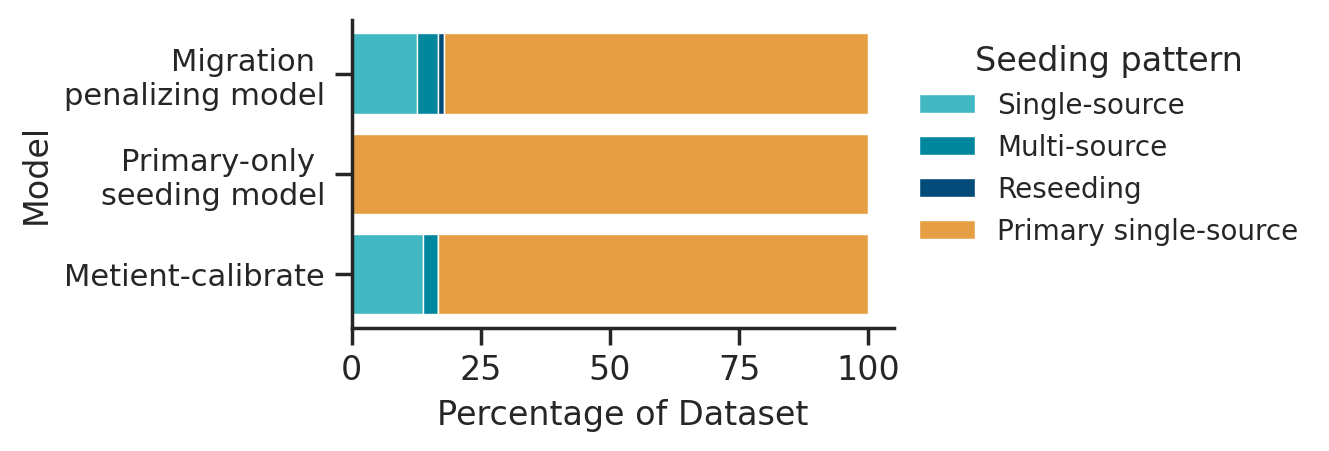

In [24]:


model_name_map = {"Top cal seeding pattern":"Metient-calibrate", 
                  "Lowest ss seeding pattern":"Primary-only \nseeding model", 
                  "Lowest mig seeding pattern":"Migration \npenalizing model"}

unique_patterns = set()
for key in model_name_map.keys():
    unique_patterns.update(trees_df[key].unique())
unique_patterns = list(unique_patterns)

data = {model:{pattern.capitalize():0 for pattern in unique_patterns} for model in model_name_map.values()}
print("Unique patterns:", unique_patterns)
data

for i, row in trees_df.iterrows():
    for key in model_name_map.keys():
        pattern = row[key].capitalize()
        data[model_name_map[key]][pattern] += 1
proportions ={model: {pattern: count/len(trees_df)*100 for pattern, count in patterns.items()} 
 for model, patterns in data.items()}
proportions

category_proportions = pd.DataFrame(proportions).T
bottoms = np.zeros(len(category_proportions))
fig, ax = plt.subplots(figsize=(3.5,2),dpi=200)
desired_order_general = ['Single-source', 'Multi-source', 'Reseeding', 'Primary single-source']
print(category_proportions)
tab_colors = ["#41b7c2", "#00879e", "#034c79", "#e59e43",]
colors = {d:c for d,c in zip(desired_order_general, tab_colors)}
# Plot each category
for column_name in desired_order_general:
    column_data = category_proportions[column_name]
    ax.barh(category_proportions.index, column_data,left=bottoms, label=column_name, 
           color=colors[column_name], edgecolor='white', linewidth=0.5)
    bottoms += column_data.values

ax.set_xlabel('Percentage of Dataset', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.tick_params(axis='x', labelsize=12)


legend = ax.legend(title='Seeding pattern', bbox_to_anchor=(1, 1), loc='upper left', frameon=False, fontsize=10)  # Place legend outside the plot
for text in legend.get_texts():
    text.set_text(text.get_text().capitalize())

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_distribution.png"), dpi=300,  bbox_inches='tight', pad_inches=0.05)
plt.show()


[('Melanoma', 'HGSOC'), ('Melanoma', 'NSCLC'), ('HR-NB', 'NSCLC')] [0.02929291345407915, 0.005585011922050718, 0.011526697059966931]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Melanoma v.s. HGSOC: Custom statistical test, P_val:2.929e-02
HR-NB v.s. NSCLC: Custom statistical test, P_val:1.153e-02
Melanoma v.s. NSCLC: Custom statistical test, P_val:5.585e-03
[] []


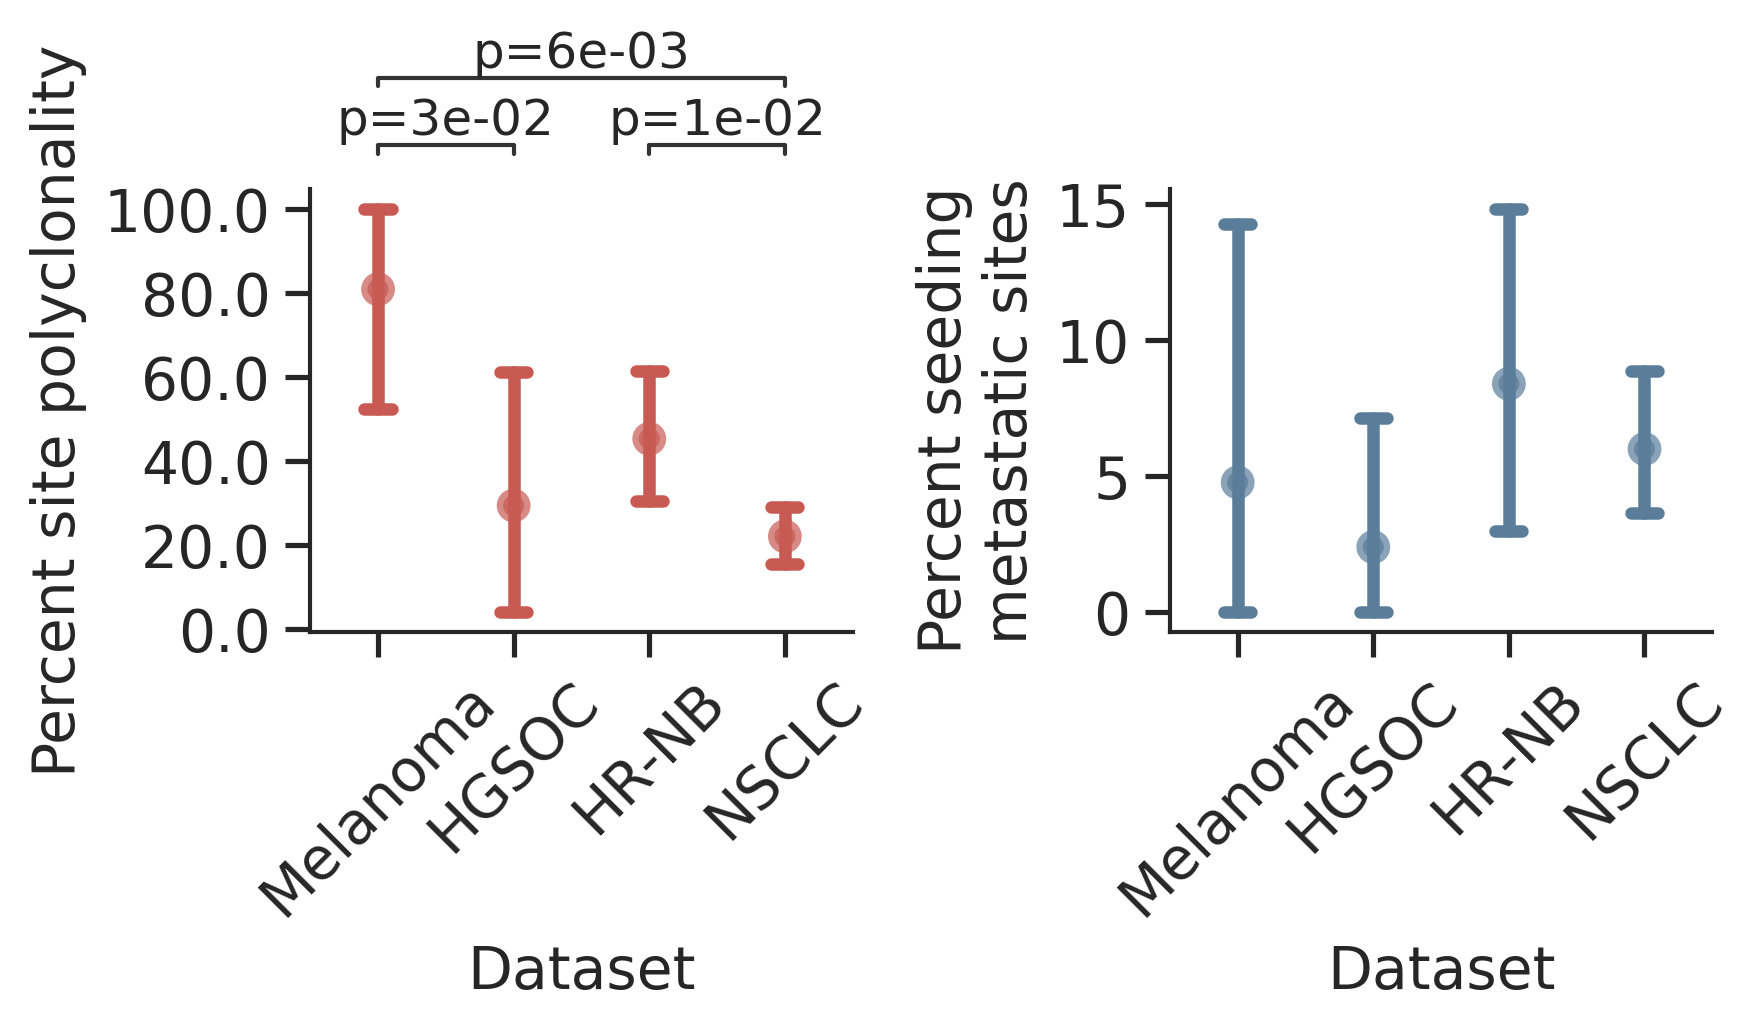

In [25]:
from statannotations.Annotator import Annotator
import itertools
import scipy
from statannot import add_stat_annotation

# Add the number of patients to the dataset labels
size_mapping = {
    dataset: f"{dataset}\n(n={len(df[df['Dataset']==dataset]['Patient id'].unique())})"
    for dataset in ['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma']
}

def get_significant_pairs(df, key, datasets):
    significant_pairs, p_values = [], []
    for pair in itertools.combinations(datasets, 2):
        group1 = df[df['Dataset'] == pair[0]][key]
        group2 = df[df['Dataset'] == pair[1]][key]
        t_stat, p_val = scipy.stats.ttest_ind(group1, group2, equal_var=False)
        if p_val < 0.05:
            significant_pairs.append(pair)
            p_values.append(p_val)
    return significant_pairs, p_values

def add_statistical_annotations(snsfig1, df, key, order, fontsize=12):
     # Perform Welch's t-test for all pairs

    significant_pairs, p_values = get_significant_pairs(df, key, order)
    print(significant_pairs, p_values)
    if len(significant_pairs) > 0:
        add_stat_annotation(snsfig1, data=df, x='Dataset', y=key,
                        box_pairs=significant_pairs, order=order, line_offset=0.08,
                        text_annot_custom=[f'p={p:.0e}' for p in p_values],pvalues = p_values,
                        perform_stat_test=False,loc='outside',linewidth=1.0,line_offset_to_box=0.2,
                        fontsize=fontsize, text_offset=0.05)

def point_plot_comparing_datasets(df, keys, ylims, ylabels, output_name):
    df = df.copy(deep=True)
    
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,4), dpi=300)
    order = ['Melanoma','HGSOC','HR-NB', 'NSCLC']
    
    # First subplot
    snsfig1 = sns.pointplot(data=df, x='Dataset', y=keys[0], errwidth=3, order=order,scale=1.5,
                           dodge=True, markers='.', errorbar='se', color='#c85a53',
                           capsize=0.2, ax=ax1, linestyles='')
    
    add_statistical_annotations(snsfig1, df, keys[0], order)

    snsfig1.set_xticklabels(snsfig1.get_xticklabels(), rotation=45, 
                            horizontalalignment='center', fontsize=14)
    snsfig1.set_yticklabels(snsfig1.get_yticks(), fontsize=14)
    ax1.set_xlabel("Dataset", fontsize=14)
    ax1.set_ylabel(ylabels[0], fontsize=14)
    #ax1.set_ylim(ylims[0])
    snsfig1.spines['top'].set_visible(False)
    snsfig1.spines['right'].set_visible(False)
    plt.setp(snsfig1.collections, alpha=0.7)

    # Second subplot  
    snsfig2 = sns.pointplot(data=df, x='Dataset', y=keys[1], errwidth=3, order=order, scale=1.5,
                           dodge=True, markers='.', errorbar='se', color='#5a7d9a',
                           capsize=0.2, ax=ax2, linestyles='')
    
    add_statistical_annotations(snsfig2, df, keys[1], order)
    
    snsfig2.set_xticklabels(snsfig2.get_xticklabels(), rotation=45, 
                            horizontalalignment='center', fontsize=14)
    plt.setp(snsfig2.get_yticklabels(), size=14)
    ax2.set_xlabel("Dataset", fontsize=14)
    ax2.set_ylabel(ylabels[1], fontsize=14)
    #ax2.set_ylim(ylims[1])
    snsfig2.spines['top'].set_visible(False)
    snsfig2.spines['right'].set_visible(False)
    plt.setp(snsfig2.collections, alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_distribution.png"), dpi=500, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()

point_plot_comparing_datasets(
    trees_df,
    ['Top cal % migs poly', 'Top cal % metastatic sites'],
    [(0,105), (-4,15)],
    ["Percent site polyclonality", 
     "Percent seeding \nmetastatic sites"],
    'combined_percent_polyclonal_met_sites'
)


[('Melanoma', 'HGSOC'), ('Melanoma', 'NSCLC'), ('HR-NB', 'NSCLC')] [0.02929291345407915, 0.005585011922050718, 0.011526697059966931]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Melanoma v.s. HGSOC: Custom statistical test, P_val:2.929e-02
HR-NB v.s. NSCLC: Custom statistical test, P_val:1.153e-02
Melanoma v.s. NSCLC: Custom statistical test, P_val:5.585e-03
[('Melanoma', 'HR-NB'), ('Melanoma', 'NSCLC'), ('HGSOC', 'HR-NB'), ('HGSOC', 'NSCLC'), ('HR-NB', 'NSCLC')] [1.708509276327499e-28, 1.4232739392949667e-22, 1.708509276327499e-28, 1.4232739392949667e-22, 2.544143174033924e-23]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

HGSOC v.s. HR-NB: Custom statistical test, P_val:1.709e-28
HR-NB v.s. NSCLC: Custom statistical test, P_val:2.544e-23
Melanoma v.s.

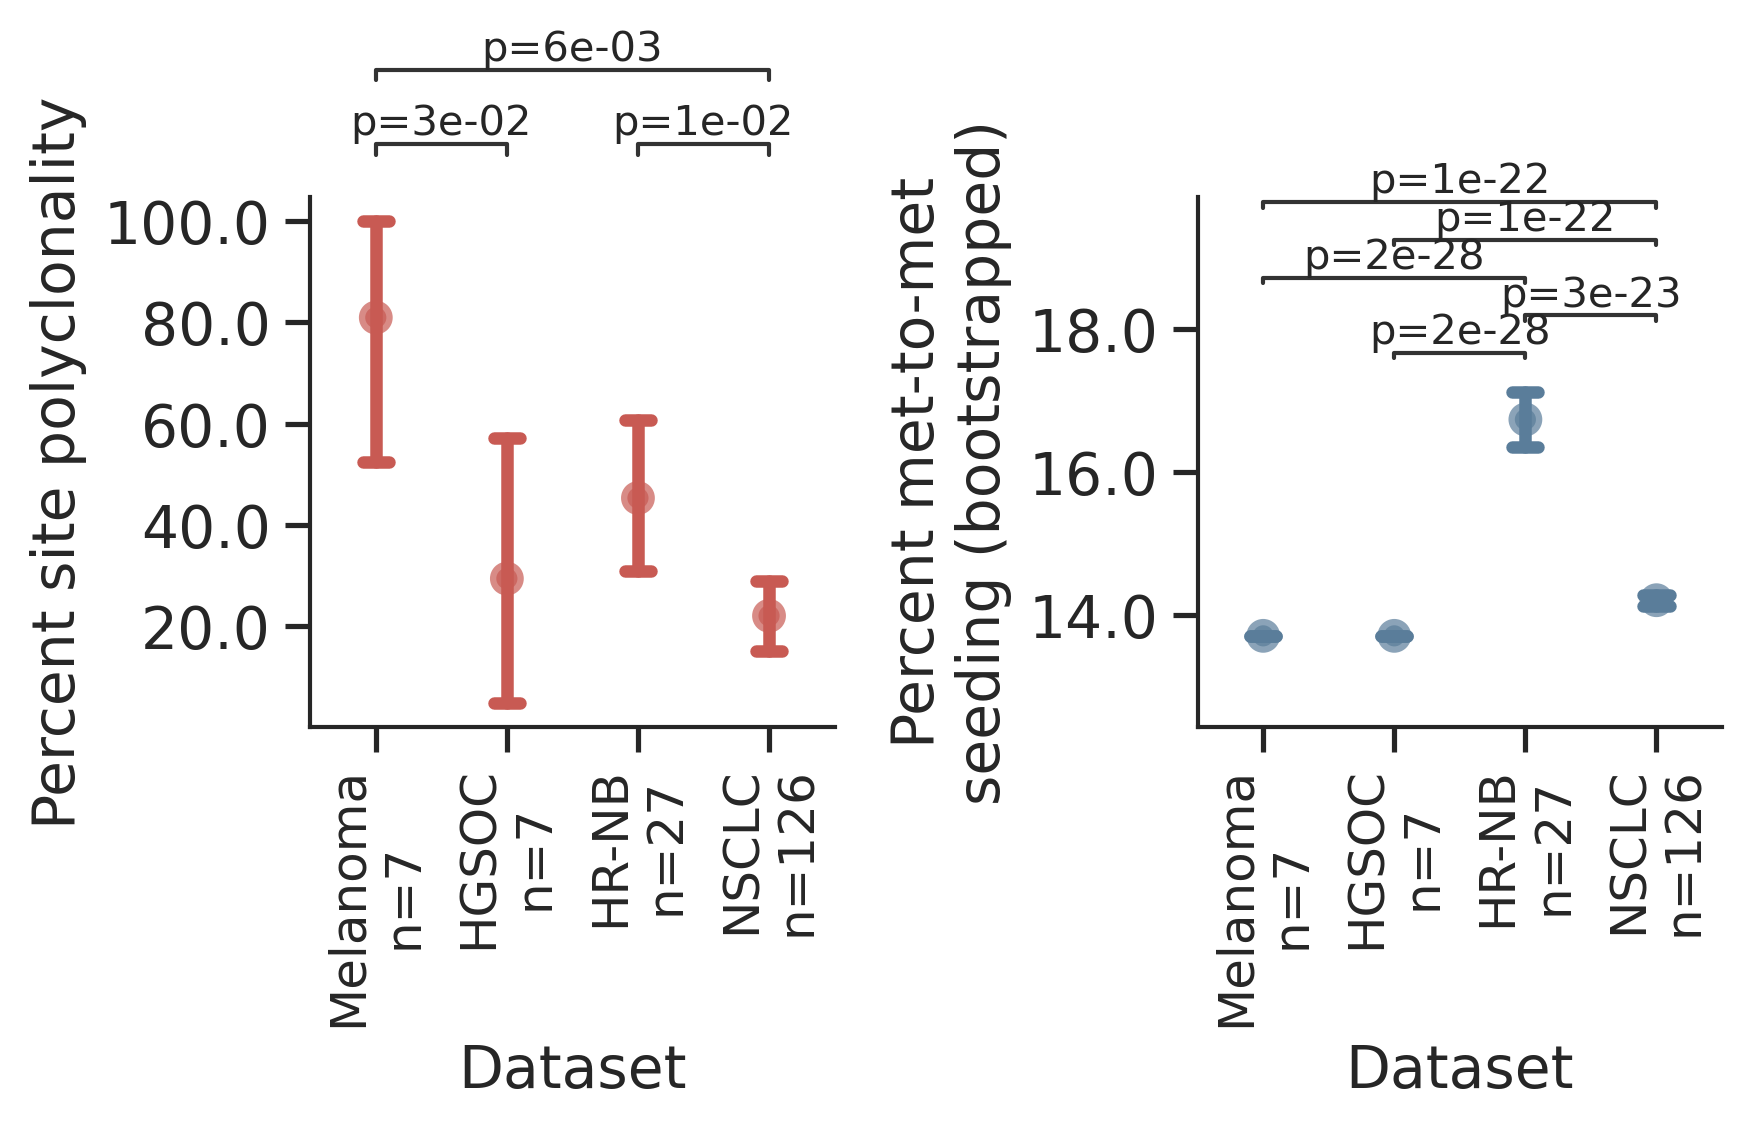

In [37]:
def get_bootstrap_pattern_percentages(trees_df):
    """Calculate percentage of non-primary-single-source patterns per dataset and bootstrap.
    
    Args:
        trees_df (pd.DataFrame): DataFrame containing bootstrap pattern data
        
    Returns:
        pd.DataFrame: DataFrame with columns Dataset, Bootstrap, NonPrimaryPercent
    """
    data = []
    datasets = trees_df['Dataset'].unique()
    num_bootstraps = len(trees_df['All bootstrap patterns'].iloc[0])
    
    for dataset in datasets:
        dataset_patterns = trees_df[trees_df['Dataset'] == dataset]['All bootstrap patterns']
        for i in range(num_bootstraps):
            patterns_at_i = [patterns[i] for patterns in dataset_patterns]
            non_primary_pct = sum(1 for p in patterns_at_i if p != 'primary single-source') / len(patterns_at_i) * 100
            data.append([dataset, i, non_primary_pct])
            
    return pd.DataFrame(data, columns=['Dataset', 'Bootstrap', 'Percent met-to-met seeding'])

# Create dataset labels with counts
name_mapping = {
    dataset: f"{dataset}\nn={len(df[df['Dataset']==dataset]['Patient id'].unique())}"
    for dataset in ['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma']
}

def side_by_side_site_polyclonalitybootstrap_patterns(trees_df, bootstrap_patterns_df, y_labels, output_name):
    df = trees_df.copy(deep=True)
    
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,4.3), dpi=300)
    order = ['Melanoma','HGSOC','HR-NB', 'NSCLC']
    
    # First subplot
    snsfig1 = sns.pointplot(data=df, x='Dataset', y='Top cal % migs poly', errwidth=3, order=order,scale=1.5,
                           dodge=True, markers='.', errorbar='se', color='#c85a53',
                           capsize=0.2, ax=ax1, linestyles='')
    
    add_statistical_annotations(snsfig1, df, 'Top cal % migs poly', order, fontsize=10)

    snsfig1.set_xticklabels([name_mapping[label.get_text()] for label in snsfig1.get_xticklabels()], 
                            rotation=90, horizontalalignment='center', fontsize=12)
    snsfig1.set_yticklabels(snsfig1.get_yticks(), fontsize=14)
    ax1.set_xlabel("Dataset", fontsize=14)
    ax1.set_ylabel(y_labels[0], fontsize=14)
    snsfig1.spines['top'].set_visible(False)
    snsfig1.spines['right'].set_visible(False)
    plt.setp(snsfig1.collections, alpha=0.7)

    # Second subplot
    snsfig2 = sns.pointplot(data=bootstrap_patterns_df, x='Dataset', y='Percent met-to-met seeding', errwidth=3, order=order,scale=1.5,
                            dodge=True, markers='.', errorbar='se', color='#5a7d9a',
                            capsize=0.2, ax=ax2, linestyles='')

    add_statistical_annotations(snsfig2, bootstrap_patterns_df,'Percent met-to-met seeding', order, fontsize=10)
    snsfig2.set_xticklabels([name_mapping[label.get_text()] for label in snsfig2.get_xticklabels()], 
                            rotation=90, horizontalalignment='center', fontsize=12)
    snsfig2.set_yticklabels(snsfig2.get_yticks(), fontsize=14)
    ax2.set_xlabel("Dataset", fontsize=14)
    ax2.set_ylabel(y_labels[1], fontsize=14)
    ax2.set_ylim(min(bootstrap_patterns_df['Percent met-to-met seeding']),max(bootstrap_patterns_df['Percent met-to-met seeding']))
    snsfig2.spines['top'].set_visible(False)
    snsfig2.spines['right'].set_visible(False)
    plt.setp(snsfig2.collections, alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_distribution.png"), dpi=500, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()


bootstrap_patterns_df = get_bootstrap_pattern_percentages(trees_df)

side_by_side_site_polyclonalitybootstrap_patterns(
    trees_df, 
    bootstrap_patterns_df, 
    ["Percent site polyclonality",'Percent met-to-met\nseeding (bootstrapped)'], 
    'combined_percent_polyclonal_met_sites_bootstrap_patterns'
)




In [27]:
bootstrap_patterns_df

,Dataset,Bootstrap,Percent met-to-met seeding
0,HGSOC,0,14.286
1,HGSOC,1,14.286
2,HGSOC,2,14.286
3,HGSOC,3,14.286
4,HGSOC,4,14.286
...,...,...,...
395,NSCLC,95,15.873
396,NSCLC,96,15.873
397,NSCLC,97,15.873
398,NSCLC,98,15.873


In [28]:
trees_df.groupby('Dataset')['Top cal % metastatic sites'].mean()

Dataset
HGSOC      2.381
HR-NB      8.395
Melanoma   4.762
NSCLC      5.992
Name: Top cal % metastatic sites, dtype: float64

[('NSCLC', 'NSCLC')] [6.53078220334289e-05]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

NSCLC v.s. NSCLC: Custom statistical test, P_val:6.531e-05


[('HR-NB', 'HR-NB'), ('NSCLC', 'NSCLC')] [0.025636610481979526, 0.0016598603534028855]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

HR-NB v.s. HR-NB: Custom statistical test, P_val:2.564e-02
NSCLC v.s. NSCLC: Custom statistical test, P_val:1.660e-03


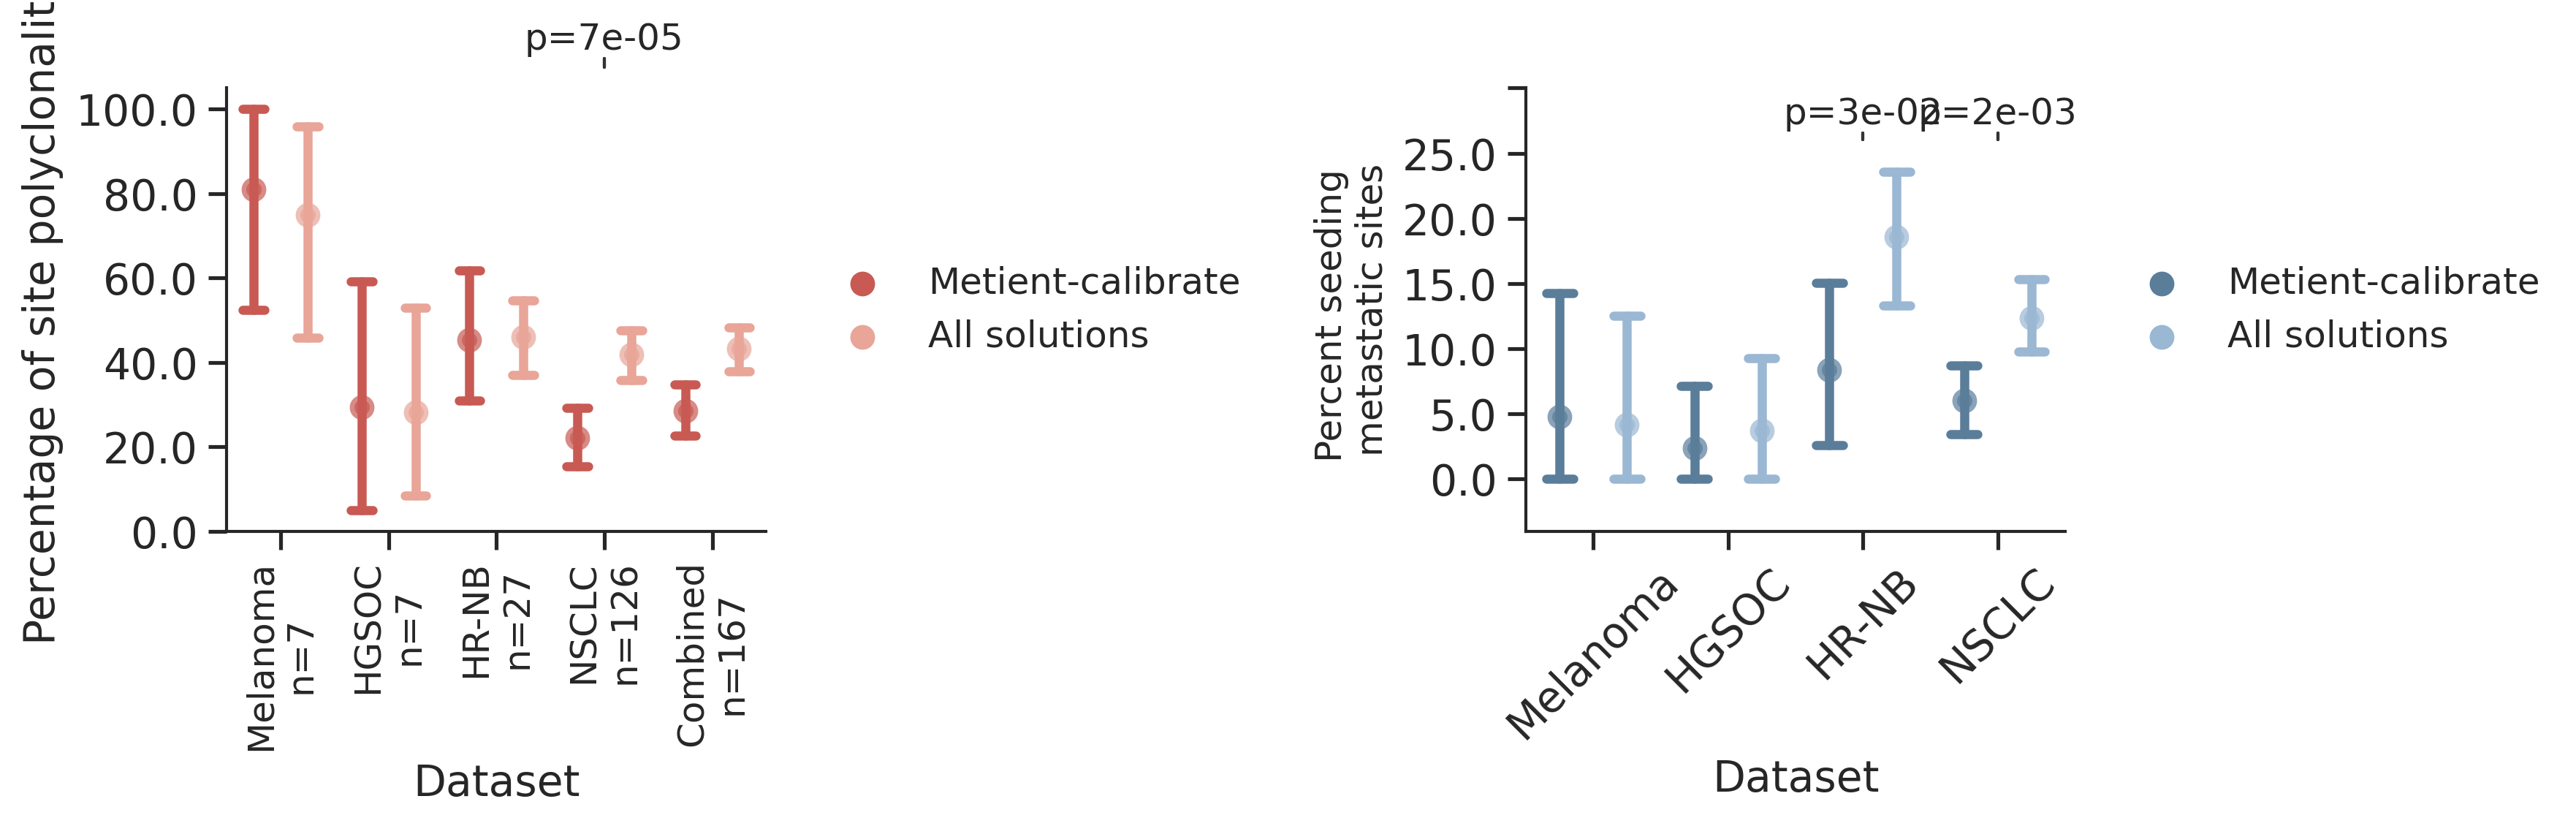

In [29]:


def get_all_solns_df(df):
    all_solns_data = []
    for _,row in trees_df.iterrows():
        migs_poly = [float(x) for x in row['All % migs poly']]
        met_sites = [float(x) for x in row['All % met sites']]
        for x in range(len(migs_poly)):

            all_solns_data.append([row['Dataset'], row['Patient id'], 'All solutions', migs_poly[x], met_sites[x]])

        all_solns_data.append([row['Dataset'], row['Patient id'], 'Metient-calibrate', row['Top cal % migs poly'], row['Top cal % metastatic sites']])

    all_solns_df = pd.DataFrame(all_solns_data, columns=['Dataset', 'Patient id', 'Solution type', '% migs poly', '% met sites'])
    return all_solns_df

def add_significance_annotations(snsfig, all_solns_df, order, key):
    # Create pairs comparing Metient-calibrate vs All solutions for each dataset
    significant_pairs = []
    p_values = []
    for dataset in order:
        dataset_data = all_solns_df[all_solns_df['Dataset'] == dataset]
        metient_data = dataset_data[dataset_data['Solution type'] == 'Metient-calibrate'][key]
        all_solns_data = dataset_data[dataset_data['Solution type'] == 'All solutions'][key]
        stat, p = stats.ttest_ind(metient_data, all_solns_data)
        if p < 0.05:
            significant_pairs.append((dataset, dataset))
            p_values.append(p)
    print(significant_pairs, p_values)
    add_stat_annotation(snsfig, data=all_solns_df, x='Dataset', y=key,
                        box_pairs=significant_pairs, order=order, line_offset=0.05,
                        text_annot_custom=[f'p={p:.0e}' for p in p_values], pvalues=p_values,
                        perform_stat_test=False, loc='outside', linewidth=1.0, line_offset_to_box=0.2,
                        fontsize=12, text_offset=0.5, line_height=0.02)

def point_plot_comparing_datasets_with_all_solns(df, ylims, ylabels, output_name):
    df = df.copy(deep=True)
    

    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), dpi=300,)
    order = ['Melanoma','HGSOC','HR-NB', 'NSCLC']
    
    all_solns_df = get_all_solns_df(df)

    # First subplot - two distributions
    # Add 'Combined' dataset by copying and modifying the data
    all_solns_df_with_all = all_solns_df.copy()
    all_data = all_solns_df.copy()
    all_data['Dataset'] = 'Combined'
    all_solns_df_with_all = pd.concat([all_solns_df_with_all, all_data])
    
    order_with_all = order + ['Combined'] 
    
    snsfig1 = sns.pointplot(data=all_solns_df_with_all, x='Dataset', y='% migs poly', hue='Solution type', errwidth=3, order=order_with_all, scale=1.5, 
                            hue_order=['Metient-calibrate', 'All solutions'],dodge=0.5, markers='.', errorbar='se', palette=['#c85a53', '#e8a598'],
                            capsize=0.2, ax=ax1, linestyles='')
    
    add_significance_annotations(snsfig1, all_solns_df, order, '% migs poly')
    name_mapping = {
                    dataset: f"{dataset}\nn={len(all_solns_df_with_all[all_solns_df_with_all['Dataset']==dataset]['Patient id'].unique())}"
                    for dataset in ['NSCLC', 'HR-NB', 'HGSOC', 'Melanoma', 'Combined']
                   }
    snsfig1.set_xticklabels([name_mapping[label.get_text()] for label in snsfig1.get_xticklabels()], 
                            rotation=90, horizontalalignment='center', fontsize=12)

    # snsfig1.set_xticklabels(snsfig1.get_xticklabels(), rotation=90, 
    #                         horizontalalignment='center', fontsize=14)
    snsfig1.set_yticklabels(snsfig1.get_yticks(), fontsize=14)
    ax1.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False, fontsize=12)

    ax1.set_xlabel("Dataset", fontsize=14)
    ax1.set_ylabel(ylabels[0], fontsize=14)
    ax1.set_ylim(ylims[0])

    snsfig1.spines['top'].set_visible(False)
    snsfig1.spines['right'].set_visible(False)
    plt.setp(snsfig1.collections, alpha=0.7)

    # Second subplot - two distributions
    snsfig2 = sns.pointplot(data=all_solns_df, x='Dataset', y='% met sites', hue='Solution type', errwidth=3, order=order, scale=1.5,
                            hue_order=['Metient-calibrate', 'All solutions'], dodge=0.5, markers='.', errorbar='se', palette=['#5a7d9a', '#9ab7d3'],
                            capsize=0.2, ax=ax2, linestyles='')
    
    add_significance_annotations(snsfig2, all_solns_df, order, '% met sites')

    snsfig2.set_xticklabels(snsfig2.get_xticklabels(), rotation=45, 
                            horizontalalignment='center', fontsize=14)
    snsfig2.set_yticklabels(snsfig2.get_yticks(), fontsize=14)
    ax2.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False, fontsize=12)
    ax2.set_xlabel("Dataset", fontsize=14)
    ax2.set_ylabel(ylabels[1], fontsize=12)
    ax2.set_ylim(ylims[1])

    snsfig2.spines['top'].set_visible(False)
    snsfig2.spines['right'].set_visible(False)
    plt.setp(snsfig2.collections, alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_met_cal_vs_all_sites_distribution.png"), dpi=500, bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close()


    
point_plot_comparing_datasets_with_all_solns(
    trees_df,
    [(0,105), (-4,30)],
    ["Percentage of site polyclonality", 
     "Percent seeding \nmetastatic sites"],
    'combined_percent_polyclonal_met_sites'
)


Lowest ss num ss v.s. Top cal num ss: t-test paired samples, P_val=1.538e-07 stat=-5.482e+00


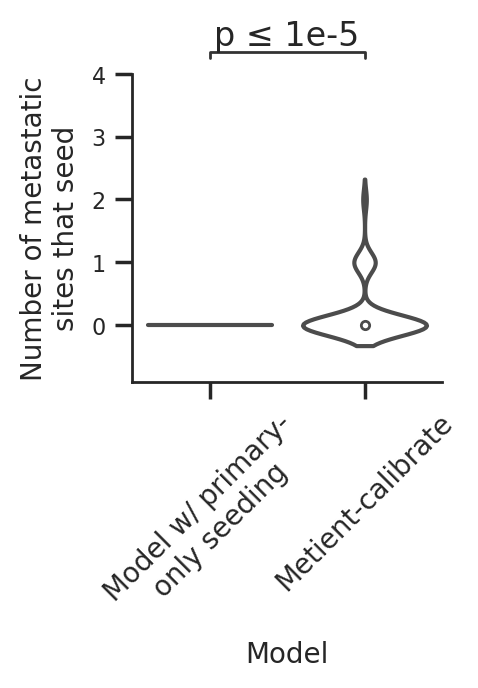

In [30]:

def violin_plot_comparison(df, keys,ylim, ylabel,output_name,subtract_one=False,):
    df = df.copy(deep=True)
    df_long = df.melt(value_vars=keys, var_name='Type', value_name='Value')
    if subtract_one: # for metastatic seeding sites vs all seeding sites
        df_long['Value'] = df_long['Value'] - 1
    sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 6, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2,2), dpi=200)
    
    types = df_long['Type'].unique()
    colors = ["#d44432", "#06879e"]
 
    snsfig = sns.violinplot(data=df_long, x='Type', y='Value', 
                           dodge=True, )
    for violin in plt.gca().collections:
        violin.set_facecolor('white')
        violin.set_edgecolor('black')  # Ensure black borders

    snsfig.set_xticklabels(['Model w/ primary-\nonly seeding', 'Metient-calibrate'], rotation=45, fontsize=10)

    plt.xlabel("Model", fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.ylim(ylim[0],ylim[1])
    add_stat_annotation(snsfig, data=df_long, x='Type', y="Value",
                        box_pairs=[keys], line_offset=0.05,
                        test='t-test_paired', text_format='simple', loc='outside', line_offset_to_box=0.00005,
                        text_offset=0.00001, verbose=2, fontsize=12, comparisons_correction=None, linewidth=1.0,
                        )
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.7)
    plt.savefig(os.path.join(OUTPUT_DIR,f"{output_name}_violinplot_ssmodel_vs_calmodel.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()

# violin_plot_comparison(no_bc_df, ['Lowest ss % migs poly', 'Top cal % migs poly'],(-40,140),"Percent of migrations\nthat are polyclonal","percent_polyclonal")
violin_plot_comparison(trees_df, ['Lowest ss num ss', 'Top cal num ss'],(-0.9,4),"Number of metastatic\nsites that seed", "number_met_ss",subtract_one=True, )



['#d4892a', '#5a9e09', '#b84988', '#06879e']


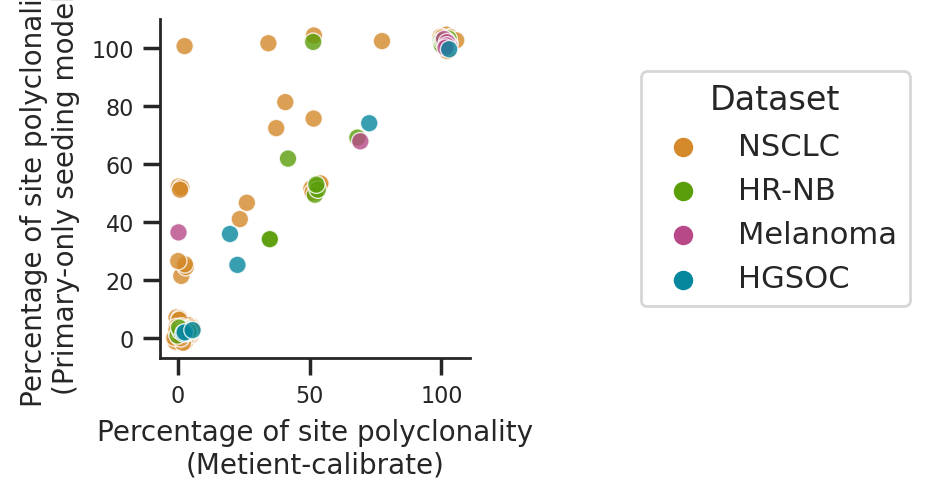

In [31]:

dataset_order = ['NSCLC','HR-NB','Melanoma','HGSOC']
colors = [four_dataset_colors[d] for d in dataset_order]
print(colors)

def jitter(values,j):
    return values + np.random.normal(j,1.5,values.shape)

def scatter_plot_comparison(df, keys, output_name): 
    df = df.copy(deep=True)   
    sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2,2.2), dpi=200)
    df['Dataset'] = pd.Categorical(df['Dataset'], categories=dataset_order, ordered=True)
    # Sort the DataFrame based on the custom order of the 'Department' column
    df = df.sort_values(by='Dataset')
    snsfig = sns.scatterplot(x=jitter(df[keys[0]], 2), y=jitter(df[keys[1]], 2), 
                             hue='Dataset', data=df, s=40,palette=colors)
    
    snsfig.legend(loc='center left', bbox_to_anchor=(1.5, 0.5), title='Dataset')
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.8)
    plt.xlabel("Percentage of site polyclonality\n(Metient-calibrate)", fontsize=10)
    plt.ylabel("Percentage of site polyclonality\n(Primary-only seeding model)", fontsize=10)
    plt.savefig(os.path.join(OUTPUT_DIR,f"scatter_plot_ssmodel_vs_calmodel_percent_polyclonal.png"), dpi=500,  bbox_inches='tight', pad_inches=0.3)
    plt.show()
    plt.close()

scatter_plot_comparison(trees_df, ['Top cal % migs poly', 'Lowest ss % migs poly'], 'blah')


### What would the seeding pattern distributions be if we adopted the tie breaking model? (minimize migration # first, then comigration then seeding site)

In [32]:
import glob

data = []
for calibrate_dir,dataset in zip(CALIBRATE_DIRS, DATASET_NAMES):

    matching_files = glob.glob(f'{calibrate_dir}/*pkl.gz')
    patients = [m.split("/")[-1].split("_")[0] for m in matching_files]
    print("\n", dataset, len(patients))
    patterns = []
    for patient, fn in zip(patients, matching_files):
        pars_metrics = []
        with gzip.open(fn, 'rb') as f:
            pkl = pickle.load(f)
            loss_dicts = pkl[OUT_LOSS_DICT_KEY]
            for l in loss_dicts:
                pars_metrics.append((int(l[MIG_KEY]), int(l[COMIG_KEY]), int(l[SEEDING_KEY])))
            sorted_indices = sorted(enumerate(pars_metrics), key=lambda x: (x[1][0], x[1][1], x[1][2]))
            best_index = sorted_indices[0][0]
            if best_index != 0: 
                print("Different result:", dataset, patient)
            V = torch.tensor(pkl[OUT_LABElING_KEY][best_index])
            A = dutil.adjacency_matrix_from_parents(pkl[OUT_ADJ_KEY][best_index])
                
            pattern = putil.seeding_pattern(V,A)
            patterns.append(pattern)
            data.append([dataset, SEEDING_PATTERN_ORDER.index(pattern)])
    print(set(patterns))
    
    counts = Counter({p: 0 for p in SEEDING_PATTERN_ORDER})
    # Update counts with actual counts from data
    counts.update(patterns)
    print(counts)

tie_scheme_df = pd.DataFrame(data, columns=['Dataset', 'Seeding pattern'])



 HGSOC 13
{'single-source', 'multi-source', 'primary single-source', 'reseeding'}
Counter({'primary single-source': 9, 'single-source': 2, 'multi-source': 1, 'reseeding': 1})

 Melanoma 7
{'single-source', 'primary single-source'}
Counter({'primary single-source': 6, 'single-source': 1, 'multi-source': 0, 'reseeding': 0})

 HR-NB 30
Different result: HR-NB H132387
Different result: HR-NB H134821
Different result: HR-NB H132374
{'multi-source', 'single-source', 'primary single-source', 'reseeding'}
Counter({'primary single-source': 22, 'single-source': 5, 'multi-source': 2, 'reseeding': 1})

 NSCLC 128
Different result: NSCLC CRUK0290
{'multi-source', 'single-source', 'primary single-source', 'reseeding'}
Counter({'primary single-source': 107, 'single-source': 15, 'multi-source': 4, 'reseeding': 2})
